In [41]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
df = pd.read_csv("ai_financial_market_daily_realistic_synthetic.csv")
df

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41
2,2015-01-03,OpenAI,4.50,0.61,-38.88,NaN,0.23
3,2015-01-04,OpenAI,5.45,0.95,-5.34,NaN,0.93
4,2015-01-05,OpenAI,3.40,1.48,48.45,NaN,-0.09
...,...,...,...,...,...,...,...
10954,2024-12-27,Meta,100.19,103.54,417.68,NaN,-0.66
10955,2024-12-28,Meta,99.12,102.37,411.86,NaN,-0.57
10956,2024-12-29,Meta,98.95,103.11,415.54,NaN,-0.52
10957,2024-12-30,Meta,100.74,103.21,416.03,NaN,0.22


In [9]:
# Basic info of the Dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10959 entries, 0 to 10958
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 10959 non-null  object 
 1   Company              10959 non-null  object 
 2   R&D_Spending_USD_Mn  10959 non-null  float64
 3   AI_Revenue_USD_Mn    10959 non-null  float64
 4   AI_Revenue_Growth_%  10959 non-null  float64
 5   Event                233 non-null    object 
 6   Stock_Impact_%       10959 non-null  float64
dtypes: float64(4), object(3)
memory usage: 599.4+ KB


In [25]:
df['Date'] = pd.to_datetime(df["Date"])

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10959 entries, 0 to 10958
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 10959 non-null  datetime64[ns]
 1   Company              10959 non-null  object        
 2   R&D_Spending_USD_Mn  10959 non-null  float64       
 3   AI_Revenue_USD_Mn    10959 non-null  float64       
 4   AI_Revenue_Growth_%  10959 non-null  float64       
 5   Event                233 non-null    object        
 6   Stock_Impact_%       10959 non-null  float64       
dtypes: datetime64[ns](1), float64(4), object(2)
memory usage: 599.4+ KB


In [17]:
df.Company.unique()

array(['OpenAI', 'Google', 'Meta'], dtype=object)

In [27]:
# Create a new column for "Year" only
df["Year"] = df["Date"].dt.year

In [28]:
df

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year
0,1970-01-01 00:00:00.000002015,OpenAI,5.92,0.63,-36.82,NaN,-0.36,1970
1,1970-01-01 00:00:00.000002015,OpenAI,5.41,1.81,80.59,NaN,0.41,1970
2,1970-01-01 00:00:00.000002015,OpenAI,4.50,0.61,-38.88,NaN,0.23,1970
3,1970-01-01 00:00:00.000002015,OpenAI,5.45,0.95,-5.34,NaN,0.93,1970
4,1970-01-01 00:00:00.000002015,OpenAI,3.40,1.48,48.45,NaN,-0.09,1970
...,...,...,...,...,...,...,...,...
10954,1970-01-01 00:00:00.000002024,Meta,100.19,103.54,417.68,NaN,-0.66,1970
10955,1970-01-01 00:00:00.000002024,Meta,99.12,102.37,411.86,NaN,-0.57,1970
10956,1970-01-01 00:00:00.000002024,Meta,98.95,103.11,415.54,NaN,-0.52,1970
10957,1970-01-01 00:00:00.000002024,Meta,100.74,103.21,416.03,NaN,0.22,1970


How much amount the companies spent on R n D

In [31]:
df.head()

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year
0,1970-01-01 00:00:00.000002015,OpenAI,5.92,0.63,-36.82,NaN,-0.36,1970
1,1970-01-01 00:00:00.000002015,OpenAI,5.41,1.81,80.59,NaN,0.41,1970
2,1970-01-01 00:00:00.000002015,OpenAI,4.50,0.61,-38.88,NaN,0.23,1970
3,1970-01-01 00:00:00.000002015,OpenAI,5.45,0.95,-5.34,NaN,0.93,1970
4,1970-01-01 00:00:00.000002015,OpenAI,3.40,1.48,48.45,NaN,-0.09,1970


In [38]:
RD = df.groupby("Company")["R&D_Spending_USD_Mn"].sum()/1000
RD

Company
Google    423.34114
Meta      264.53307
OpenAI     26.48277
Name: R&D_Spending_USD_Mn, dtype: float64

Text(0, 0.5, 'Amount in USD_$Bn')

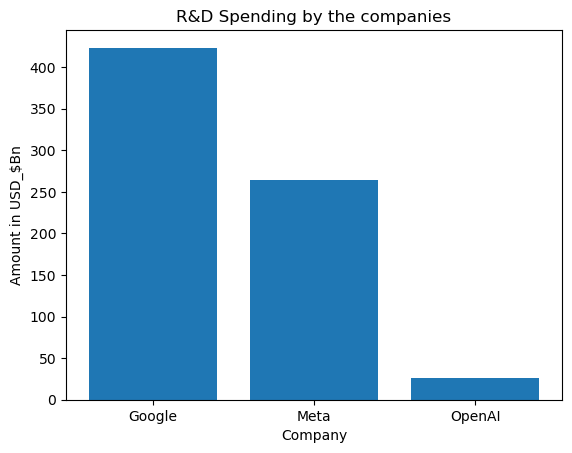

In [43]:
# Draw a bar
plt.bar(RD.index, RD.values)
plt.show

plt.title("R&D Spending by the companies")
plt.xlabel("Company")
plt.ylabel("Amount in USD_$Bn")

Revenue Earned by the companies

In [45]:
df.head()

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year
0,1970-01-01 00:00:00.000002015,OpenAI,5.92,0.63,-36.82,NaN,-0.36,1970
1,1970-01-01 00:00:00.000002015,OpenAI,5.41,1.81,80.59,NaN,0.41,1970
2,1970-01-01 00:00:00.000002015,OpenAI,4.50,0.61,-38.88,NaN,0.23,1970
3,1970-01-01 00:00:00.000002015,OpenAI,5.45,0.95,-5.34,NaN,0.93,1970
4,1970-01-01 00:00:00.000002015,OpenAI,3.40,1.48,48.45,NaN,-0.09,1970


In [50]:
RV = df.groupby("Company")["AI_Revenue_USD_Mn"].sum()/1000

Text(0, 0.5, 'Ammount of Revenue')

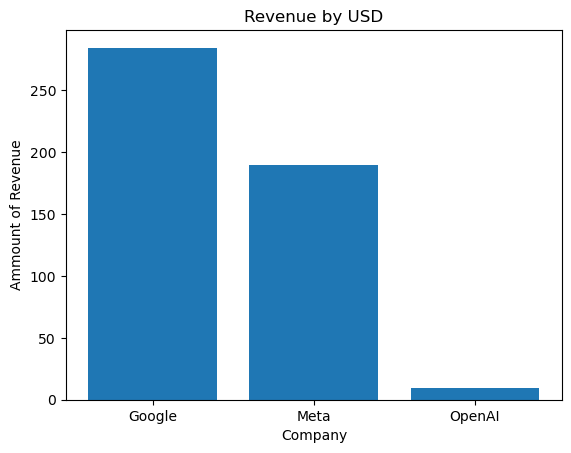

In [54]:
plt.bar(RV.index, RV.values)
plt.title("Revenue by USD")
plt.xlabel("Company")
plt.ylabel("Ammount of Revenue")

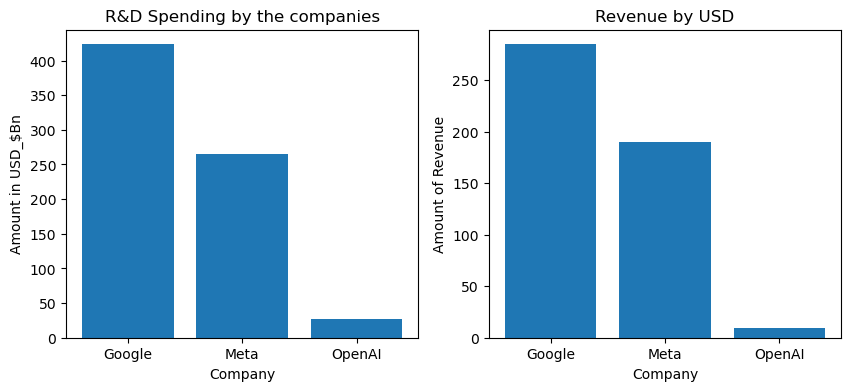

In [60]:
# Bar plot to show expenditure & revenue of the companies
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)                          # ← LEFT panel  (FIX: was already 1)
plt.bar(RD.index, RD.values)
plt.title("R&D Spending by the companies")
plt.xlabel("Company")
plt.ylabel("Amount in USD_$Bn")

plt.subplot(1,2,2)                          # ← RIGHT panel (FIXED: was 1)
plt.bar(RV.index, RV.values)
plt.title("Revenue by USD")
plt.xlabel("Company")
plt.ylabel("Amount of Revenue")

plt.show()

Datewise impact on the Stock

In [62]:
df.head()

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year
0,1970-01-01 00:00:00.000002015,OpenAI,5.92,0.63,-36.82,NaN,-0.36,1970
1,1970-01-01 00:00:00.000002015,OpenAI,5.41,1.81,80.59,NaN,0.41,1970
2,1970-01-01 00:00:00.000002015,OpenAI,4.50,0.61,-38.88,NaN,0.23,1970
3,1970-01-01 00:00:00.000002015,OpenAI,5.45,0.95,-5.34,NaN,0.93,1970
4,1970-01-01 00:00:00.000002015,OpenAI,3.40,1.48,48.45,NaN,-0.09,1970


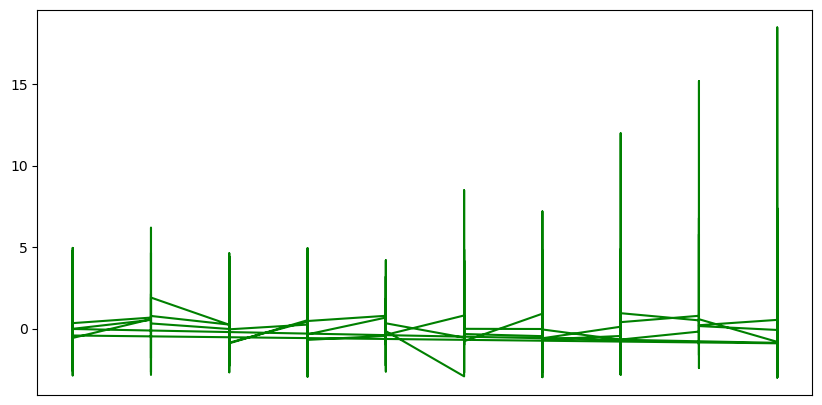

In [63]:
plt.figure(figsize=(10,5))

plt.plot(df['Date'], df["Stock_Impact_%"], color="green")

Create 3 Dataframe

In [66]:
df.head()

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year
0,1970-01-01 00:00:00.000002015,OpenAI,5.92,0.63,-36.82,NaN,-0.36,1970
1,1970-01-01 00:00:00.000002015,OpenAI,5.41,1.81,80.59,NaN,0.41,1970
2,1970-01-01 00:00:00.000002015,OpenAI,4.50,0.61,-38.88,NaN,0.23,1970
3,1970-01-01 00:00:00.000002015,OpenAI,5.45,0.95,-5.34,NaN,0.93,1970
4,1970-01-01 00:00:00.000002015,OpenAI,3.40,1.48,48.45,NaN,-0.09,1970


In [70]:
data_openAI = df[df["Company"] == "OpenAI"]
data_google = df[df["Company"] == "Google"]
data_meta = df[df["Company"] == "Meta"]

In [71]:
data_openAI

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year
0,1970-01-01 00:00:00.000002015,OpenAI,5.92,0.63,-36.82,NaN,-0.36,1970
1,1970-01-01 00:00:00.000002015,OpenAI,5.41,1.81,80.59,NaN,0.41,1970
2,1970-01-01 00:00:00.000002015,OpenAI,4.50,0.61,-38.88,NaN,0.23,1970
3,1970-01-01 00:00:00.000002015,OpenAI,5.45,0.95,-5.34,NaN,0.93,1970
4,1970-01-01 00:00:00.000002015,OpenAI,3.40,1.48,48.45,NaN,-0.09,1970
...,...,...,...,...,...,...,...,...
3648,1970-01-01 00:00:00.000002024,OpenAI,10.06,4.71,370.69,NaN,0.93,1970
3649,1970-01-01 00:00:00.000002024,OpenAI,9.67,5.32,432.15,NaN,-0.25,1970
3650,1970-01-01 00:00:00.000002024,OpenAI,9.17,5.46,445.74,NaN,0.47,1970
3651,1970-01-01 00:00:00.000002024,OpenAI,10.36,6.31,530.88,NaN,0.69,1970


In [75]:
data_google

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year
3653,1970-01-01 00:00:00.000002015,Google,79.89,30.19,0.64,NaN,-0.02,1970
3654,1970-01-01 00:00:00.000002015,Google,78.99,30.44,1.47,NaN,-0.98,1970
3655,1970-01-01 00:00:00.000002015,Google,79.20,30.46,1.53,NaN,0.78,1970
3656,1970-01-01 00:00:00.000002015,Google,79.59,30.55,1.82,NaN,-0.41,1970
3657,1970-01-01 00:00:00.000002015,Google,81.50,30.59,1.97,NaN,-0.78,1970
...,...,...,...,...,...,...,...,...
7301,1970-01-01 00:00:00.000002024,Google,162.16,155.36,417.88,NaN,-0.46,1970
7302,1970-01-01 00:00:00.000002024,Google,159.69,154.47,414.89,NaN,-0.48,1970
7303,1970-01-01 00:00:00.000002024,Google,161.69,154.59,415.31,NaN,0.72,1970
7304,1970-01-01 00:00:00.000002024,Google,158.48,155.05,416.84,NaN,-0.17,1970


In [74]:
data_meta

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year
7306,1970-01-01 00:00:00.000002015,Meta,50.39,18.95,-5.23,NaN,-0.42,1970
7307,1970-01-01 00:00:00.000002015,Meta,49.80,19.77,-1.16,NaN,0.63,1970
7308,1970-01-01 00:00:00.000002015,Meta,49.09,19.96,-0.21,NaN,0.73,1970
7309,1970-01-01 00:00:00.000002015,Meta,50.66,20.48,2.38,NaN,-0.26,1970
7310,1970-01-01 00:00:00.000002015,Meta,51.36,19.84,-0.80,NaN,-0.37,1970
...,...,...,...,...,...,...,...,...
10954,1970-01-01 00:00:00.000002024,Meta,100.19,103.54,417.68,NaN,-0.66,1970
10955,1970-01-01 00:00:00.000002024,Meta,99.12,102.37,411.86,NaN,-0.57,1970
10956,1970-01-01 00:00:00.000002024,Meta,98.95,103.11,415.54,NaN,-0.52,1970
10957,1970-01-01 00:00:00.000002024,Meta,100.74,103.21,416.03,NaN,0.22,1970
